In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


**Load the DataSet**

In [2]:
df = pd.read_csv('/content/bankmarketing.csv')

In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [4]:
df.shape

# rows = 11162
# columns = 17

(11162, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [6]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


**Exploratory Data Analysis**

In [7]:
df.isnull().sum()

# There is no null value in this dataset

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


In [8]:
(df == "unknown").sum()

,0
age,0
job,70
marital,0
education,497
default,0
balance,0
housing,0
loan,0
contact,2346
day,0


In [9]:
df['deposit'].value_counts()

# Almost half of the customers subscribed

,count
deposit,
no,5873
yes,5289


In [10]:
df['deposit'].value_counts(normalize=True)*100

# conversion rate of deposit.
# overall = 47.38%
# no = 52.61%
# yes = 47.38

,proportion
deposit,
no,52.616019
yes,47.383981


In [11]:
df['loan'].value_counts()

# count of customer who has loan.
# NO = 9702
# YES = 1460
# Majority customer do not have loan.

,count
loan,
no,9702
yes,1460


In [12]:
df['age'].describe()

,age
count,11162.000000
mean,41.231948
std,11.913369
min,18.000000
25%,32.000000
50%,39.000000
75%,49.000000
max,95.000000


In [13]:
df.groupby('job')['deposit'].value_counts()

job            deposit
admin.         no          703
               yes         631
blue-collar    no         1236
               yes         708
entrepreneur   no          205
               yes         123
housemaid      no          165
               yes         109
management     yes        1301
               no         1265
retired        yes         516
               no          262
self-employed  no          218
               yes         187
services       no          554
               yes         369
student        yes         269
               no           91
technician     no          983
               yes         840
unemployed     yes         202
               no          155
unknown        no           36
               yes          34
Name: count, dtype: int64

In [14]:
pd.crosstab(df['job'],df['deposit'],normalize='index')*100

# Deposit vs Job Analysis Coversion Rate
# Key Insights
# 1. Highest Converting Jobs
# Students → 74.7% YES
# Highest conversion rate in the dataset
# Retired → 66.3%
# management → 50.7% YES
#Balanced but strong professional segment

# 2. Medium Converting Jobs
# admin → 47.3% YES
# Almost balanced customers

# 3. Low Converting Jobs
# blue-collar → 36.4% YES
# entrepreneur → 37.5% YES
# housemaid → 39.7% YES
# These groups are less likely to invest in term deposits.



deposit,no,yes
job,,
admin.,52.698651,47.301349
blue-collar,63.580247,36.419753
entrepreneur,62.500000,37.500000
housemaid,60.218978,39.781022
management,49.298519,50.701481
retired,33.676093,66.323907
self-employed,53.827160,46.172840
services,60.021668,39.978332
student,25.277778,74.722222


In [15]:
df.groupby('deposit')['balance'].mean()

# Balance vs Deposit analysis
# Customer who has higher balance are more likely to subscribe.


,balance
deposit,
no,1280.227141
yes,1804.267915


In [16]:
pd.crosstab(df['loan'], df['deposit'], normalize='index')*100

# Loan vs Deposit Analysis
# Customer who has loan are less likely to subscribe deposit and who does not have loan are more like to subscribe deposit.


deposit,no,yes
loan,,
no,50.474129,49.525871
yes,66.849315,33.150685


In [17]:
pd.crosstab(df['housing'],df['deposit'],normalize='index')*100

# Housing Loan vs Deposit
# Customer who has housing loan are less likely to subscribe deposit and
# who does not have housing loan are more like to subscribe deposit.


deposit,no,yes
housing,,
no,42.968883,57.031117
yes,63.359212,36.640788


**Visulization**

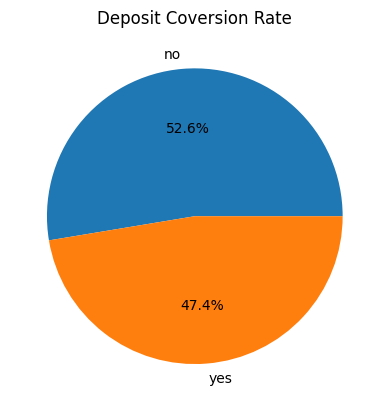

In [18]:
df['deposit'].value_counts().plot(kind ="pie", autopct = "%1.1f%%")
plt.title("Deposit Coversion Rate")
plt.ylabel("")
plt.show()

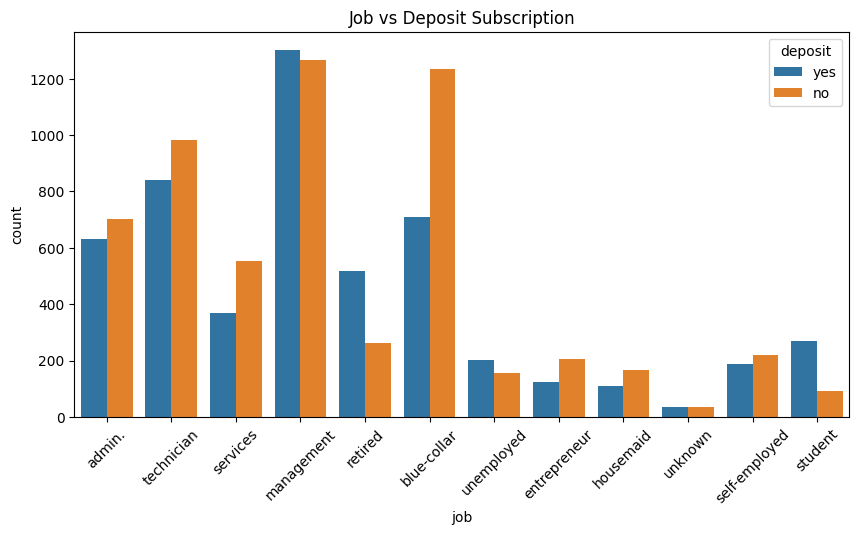

In [19]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = "job", hue = "deposit")
plt.xticks(rotation = 45)
plt.title("Job vs Deposit Subscription")
plt.show()

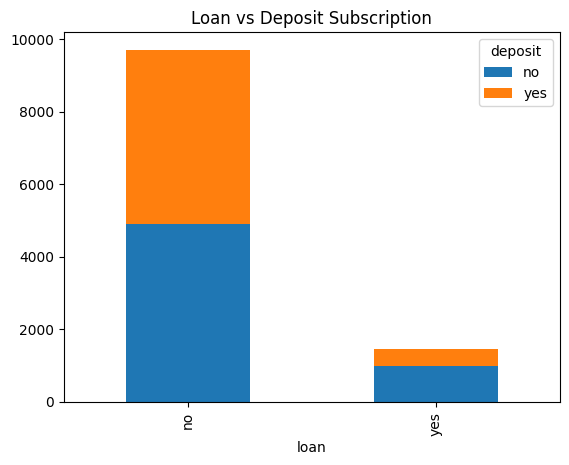

In [20]:
pd.crosstab(df['loan'],df['deposit']).plot(kind = "bar", stacked = True)
plt.title("Loan vs Deposit Subscription")
plt.show()


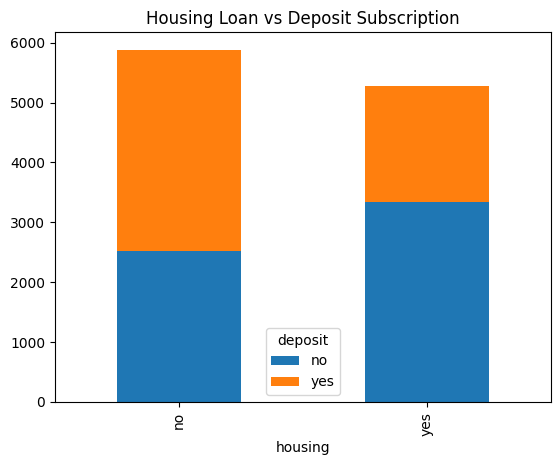

In [21]:
pd.crosstab(df['housing'],df['deposit']).plot(kind = "bar", stacked = True)
plt.title("Housing Loan vs Deposit Subscription")
plt.show()